# agentv20_a2a_streaming_events

Start the streaming A2A server first:

```bash
python -m agentv20_a2a_streaming_events.a2a_streaming_server
```


In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

A2A_STREAMING_SERVER_URL = os.getenv("A2A_STREAMING_SERVER_URL", "http://127.0.0.1:8301")
print("A2A streaming server URL:", A2A_STREAMING_SERVER_URL)
print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))


A2A streaming server URL: http://127.0.0.1:8301
OpenAI API key present: True


## HTTP helpers and SSE parser


In [2]:
import asyncio
import json
import httpx

async def get_json(path: str):
    async with httpx.AsyncClient(timeout=30.0) as client:
        response = await client.get(f"{A2A_STREAMING_SERVER_URL}{path}")
        response.raise_for_status()
        return response.json()

async def post_json(path: str, payload: dict | None = None):
    async with httpx.AsyncClient(timeout=30.0) as client:
        response = await client.post(f"{A2A_STREAMING_SERVER_URL}{path}", json=payload or {})
        response.raise_for_status()
        return response.json()

async def stream_task_events(task_id: str):
    async with httpx.AsyncClient(timeout=None) as client:
        async with client.stream("GET", f"{A2A_STREAMING_SERVER_URL}/tasks/{task_id}/events") as response:
            response.raise_for_status()
            current_event = "message"
            data_lines = []

            async for line in response.aiter_lines():
                if line == "":
                    if data_lines:
                        data_text = "\n".join(data_lines)
                        try:
                            data = json.loads(data_text)
                        except json.JSONDecodeError:
                            data = {"raw": data_text}
                        yield {"event": current_event, "data": data}
                        current_event = "message"
                        data_lines = []
                    continue

                if line.startswith("event:"):
                    current_event = line.split(":", 1)[1].strip()
                elif line.startswith("data:"):
                    data_lines.append(line.split(":", 1)[1].strip())


## Test discovery APIs


In [3]:
health = await get_json("/health")
agent_card = await get_json("/.well-known/agent.json")
model_card = await get_json("/model-card")
capabilities = await get_json("/capabilities")
skills = await get_json("/skills")

print("Health:", health)
print("Agent:", agent_card["name"])
print("Streaming capability:", capabilities["streaming"])
print("Skills:", [skill["id"] for skill in skills["skills"]])


Health: {'status': 'ok', 'agent': 'epp_streaming_incident_analysis_agent'}
Agent: EPP Streaming Incident Analysis Agent
Streaming capability: True
Skills: ['epp_incident_analysis']


## Create task and stream events


In [4]:
created = await post_json(
    "/tasks",
    {
        "input": "Investigate CHECK-DOMAIN timeout spike after R13",
        "skill_id": "epp_incident_analysis",
        "context_id": "ctx_notebook_streaming",
    },
)

task_id = created["task_id"]
print("Task ID:", task_id)
print("Initial state:", created["status"]["state"])

events = []
async for event in stream_task_events(task_id):
    print(event["event"], "-", event["data"].get("message"))
    events.append(event)
    if event["event"] in {"completed", "failed", "canceled", "rejected"}:
        break

print("Event count:", len(events))


Task ID: task_e6dbb087a81f
Initial state: submitted
status - Task submitted.
status - Collecting EPP failure metrics.
progress - Metrics collected: CHECK-DOMAIN p95 response_time near 240 ms; timeout volume elevated.
progress - Runbook context retrieved: check registry endpoint, DNS resolver, and connection pool saturation.
artifact - Artifact created: incident_analysis.
status - Task completed successfully.
completed - Final result is ready.
Event count: 7


## Fetch task, status, artifacts


In [5]:
task = await get_json(f"/tasks/{task_id}")
status = await get_json(f"/tasks/{task_id}/status")
artifacts = await get_json(f"/tasks/{task_id}/artifacts")
tasks = await get_json("/tasks")

print("Task state:", task["status"]["state"])
print("Status:", status)
print("Artifacts:", artifacts)
print("Task count:", len(tasks["tasks"]))


Task state: completed
Status: {'state': 'completed', 'message': 'Task completed successfully.', 'updated_at': 1782593076.330806}
Artifacts: {'task_id': 'task_e6dbb087a81f', 'artifacts': [{'artifact_id': 'artifact_77c7e83cbb2b', 'name': 'incident_analysis', 'parts': [{'type': 'text', 'text': 'Likely cause: CHECK-DOMAIN timeout spike is consistent with upstream registry connectivity degradation or connection pool saturation after R13. Evidence includes p95 response_time around 240 ms, increased CONNECTION_TIMEOUT volume, and concentration around peak traffic/client_b. Recommended next action: inspect registry endpoint health, DNS resolver latency, connection pool saturation, and compare pre/post-release failure volume.', 'data': None}, {'type': 'json', 'text': None, 'data': {'likely_cause': 'registry connectivity or connection pool saturation', 'primary_command': 'CHECK-DOMAIN', 'primary_failure_reason': 'CONNECTION_TIMEOUT', 'p95_response_time_ms': 240, 'recommended_actions': ['inspect 

## Test cancellation and rejection


In [6]:
cancel_task = await post_json("/tasks", {"input": "Long task to cancel", "skill_id": "epp_incident_analysis"})
cancel_task_id = cancel_task["task_id"]
canceled = await post_json(f"/tasks/{cancel_task_id}/cancel")
print("Canceled:", canceled["status"]["state"])

cancel_events = []
async for event in stream_task_events(cancel_task_id):
    print("cancel event:", event["event"], event["data"].get("message"))
    cancel_events.append(event)
    if event["event"] in {"completed", "failed", "canceled", "rejected"}:
        break

rejected = await post_json("/tasks", {"input": "Unsupported", "skill_id": "unsupported_skill"})
print("Rejected:", rejected["status"]["state"])


Canceled: canceled
cancel event: status Task submitted.
cancel event: status Collecting EPP failure metrics.
cancel event: canceled Task canceled by client.
Rejected: rejected


## Define LangGraph host state and nodes


In [7]:
from typing import NotRequired, TypedDict
from langchain_openai import ChatOpenAI

class AgentState(TypedDict):
    input: str
    agent_card: NotRequired[dict]
    capabilities: NotRequired[dict]
    task_id: NotRequired[str]
    task: NotRequired[dict]
    events: NotRequired[list[dict]]
    artifacts: NotRequired[dict]
    final_answer: NotRequired[str]

async def discover_agent_node(state: AgentState) -> AgentState:
    return {
        "agent_card": await get_json("/.well-known/agent.json"),
        "capabilities": await get_json("/capabilities"),
    }

async def submit_task_node(state: AgentState) -> AgentState:
    task = await post_json(
        "/tasks",
        {
            "input": state["input"],
            "skill_id": "epp_incident_analysis",
            "context_id": "ctx_langgraph_streaming_host",
            "metadata": {"caller": "notebook_host"},
        },
    )
    return {"task_id": task["task_id"], "task": task}

async def stream_task_node(state: AgentState) -> AgentState:
    events = []
    async for event in stream_task_events(state["task_id"]):
        print("[remote event]", event["event"], "-", event["data"].get("message"))
        events.append(event)
        if event["event"] in {"completed", "failed", "canceled", "rejected"}:
            break

    task = await get_json(f"/tasks/{state['task_id']}")
    return {"events": events, "task": task}

async def fetch_artifacts_node(state: AgentState) -> AgentState:
    artifacts = await get_json(f"/tasks/{state['task_id']}/artifacts")
    return {"artifacts": artifacts}

async def synthesize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    prompt = f'''
User request:
{state["input"]}

Remote agent:
{state["agent_card"]["name"]}

Capabilities:
{state["capabilities"]}

Streamed events:
{state["events"]}

Task:
{state["task"]}

Artifacts:
{state["artifacts"]}

Write a concise final answer based on the streamed remote A2A result.
'''
    response = await llm.ainvoke(prompt)
    return {"final_answer": response.content}


## Build graph


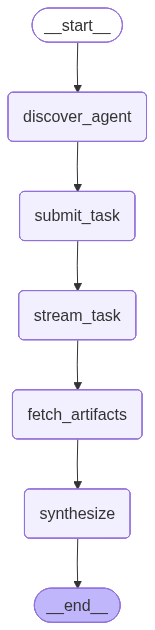

In [8]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)
    graph_builder.add_node("discover_agent", discover_agent_node)
    graph_builder.add_node("submit_task", submit_task_node)
    graph_builder.add_node("stream_task", stream_task_node)
    graph_builder.add_node("fetch_artifacts", fetch_artifacts_node)
    graph_builder.add_node("synthesize", synthesize_node)

    graph_builder.add_edge(START, "discover_agent")
    graph_builder.add_edge("discover_agent", "submit_task")
    graph_builder.add_edge("submit_task", "stream_task")
    graph_builder.add_edge("stream_task", "fetch_artifacts")
    graph_builder.add_edge("fetch_artifacts", "synthesize")
    graph_builder.add_edge("synthesize", END)

    return graph_builder.compile()

graph = build_graph()
graph


## Visualize graph


In [9]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	discover_agent(discover_agent)
	submit_task(submit_task)
	stream_task(stream_task)
	fetch_artifacts(fetch_artifacts)
	synthesize(synthesize)
	__end__([<p>__end__</p>]):::last
	__start__ --> discover_agent;
	discover_agent --> submit_task;
	fetch_artifacts --> synthesize;
	stream_task --> fetch_artifacts;
	submit_task --> stream_task;
	synthesize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## Run graph


In [10]:
result = await graph.ainvoke({
    "input": "Investigate CHECK-DOMAIN timeout spike after R13."
})

print("Remote agent:", result["agent_card"]["name"])
print("Task:", result["task_id"])
print("State:", result["task"]["status"]["state"])
print()
print(result["final_answer"])


[remote event] status - Task submitted.
[remote event] status - Collecting EPP failure metrics.
[remote event] progress - Metrics collected: CHECK-DOMAIN p95 response_time near 240 ms; timeout volume elevated.
[remote event] progress - Runbook context retrieved: check registry endpoint, DNS resolver, and connection pool saturation.
[remote event] artifact - Artifact created: incident_analysis.
[remote event] status - Task completed successfully.
[remote event] completed - Final result is ready.
Remote agent: EPP Streaming Incident Analysis Agent
Task: task_f5440c9e8c89
State: completed

The investigation into the CHECK-DOMAIN timeout spike after R13 indicates that the likely cause is related to upstream registry connectivity degradation or connection pool saturation. Evidence supporting this includes a p95 response time of approximately 240 ms and an elevated volume of CONNECTION_TIMEOUT errors, particularly concentrated around peak traffic/client_b. 

Recommended next actions include:

## Stream host graph updates


In [11]:
async for chunk in graph.astream(
    {"input": "Investigate CHECK-DOMAIN timeout spike after R13."},
    stream_mode="updates",
):
    print("\n--- host graph update ---")
    print(chunk)



--- host graph update ---
{'discover_agent': {'agent_card': {'name': 'EPP Streaming Incident Analysis Agent', 'description': 'Analyzes EPP SLA incidents and streams task progress events.', 'version': '1.0.0', 'url': 'http://127.0.0.1:8301', 'provider': {'organization': 'AgenticAI Learn', 'url': 'http://localhost'}, 'capabilities': {'streaming': True, 'pushNotifications': False, 'stateTransitionHistory': True, 'artifacts': True, 'cancellation': True}, 'defaultInputModes': ['text/plain', 'application/json'], 'defaultOutputModes': ['text/plain', 'application/json'], 'skills': [{'id': 'epp_incident_analysis', 'name': 'EPP streaming incident analysis', 'description': 'Investigates EPP SLA failures, latency, timeout spikes, and release impact with streaming progress.', 'inputModes': ['text/plain', 'application/json'], 'outputModes': ['text/plain', 'application/json'], 'examples': ['Investigate CHECK-DOMAIN timeout spike after R13']}], 'authentication': {'schemes': ['none']}}, 'capabilities'